# 52 Random Forest — Datos Scraping Manual

Réplica de `52_random_forest.ipynb` sobre los datasets de scraping manual:
- **rent**: `alquiler_idealista_clean.csv`
- **sale**: `venta_idealista_clean.csv`

**Pipeline:**
1. Creación de `log_precio` a partir del precio original
2. Eliminación de outliers en el target (`log_precio`) con método IQR antes del split
3. Preprocesado: imputación de medianas (numéricas) + OneHotEncoder (categóricas)
4. Búsqueda de hiperparámetros con `RandomizedSearchCV` + validación cruzada (CV=5)
5. Evaluación con métricas train / CV / test y análisis de sobreajuste
6. Gráficos diagnósticos: Real vs Predicho, histograma de residuos y Q-Q plot

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)

# ── Configuración global ──────────────────────────────────────────────────────
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
N_SPLITS      = 5
N_ITER_SEARCH = 50
TARGET_COL    = "log_precio"
IQR_FACTOR    = 1.5

# ── Espacio de búsqueda de hiperparámetros ────────────────────────────────────
PARAM_DIST = {
    "rf__n_estimators":      [200, 300, 500],
    "rf__max_depth":         [6, 8, 10, 12, 15],
    "rf__min_samples_split": [15, 20, 30, 50],
    "rf__min_samples_leaf":  [5, 10, 15, 20],
    "rf__max_features":      [0.3, 0.4, 0.5, 0.6],
    "rf__max_samples":       [0.7, 0.8, 0.9],
}

# ── Rutas de los datasets ─────────────────────────────────────────────────────
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del proyecto con data/processed")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SCRAPING_DIR = PROJECT_ROOT / "data" / "processed" / "scraping_manual"

DATASETS = {
    "rent": SCRAPING_DIR / "alquiler_idealista_clean.csv",
    "sale": SCRAPING_DIR / "venta_idealista_clean.csv",
}

for name, path in DATASETS.items():
    if not path.exists():
        raise FileNotFoundError(f"No se encontro {name}: {path}")

print("Datasets listos:")
for name, path in DATASETS.items():
    print(f"- {name}: {path}")

Datasets listos:
- rent: /Users/sitomachucas/Documents/BezanillaSL/data/processed/scraping_manual/alquiler_idealista_clean.csv
- sale: /Users/sitomachucas/Documents/BezanillaSL/data/processed/scraping_manual/venta_idealista_clean.csv


In [2]:
# ── Configuración de features por dataset ─────────────────────────────────────
# Cada dataset de scraping tiene columnas distintas; definimos los features
# y la columna de precio para cada uno.

DATASET_CONFIG = {
    "rent": {
        "price_col":  "precio_mensual_eur",
        "features": [
            "habitaciones",
            "superficie_m2",
            "exterior",
            "ascensor",
            "garaje_incluido",
            "tipo_inmueble_piso",
            "vistas_mar",
            "lujo",
            "es_vacacional_verano",
            "municipio",   # categórica → OHE
            "zona",        # categórica → OHE
        ],
    },
    "sale": {
        "price_col":  "precio_eur",
        "features": [
            "habitaciones",
            "superficie_m2",
            "exterior",
            "ascensor",
            "garaje_incluido",
            "obra_nueva",
            "tipo_inmueble",  # categórica → OHE
            "subtipo",        # categórica → OHE
            "municipio",      # categórica → OHE
        ],
    },
}

print("Configuración de features:")
for ds, cfg in DATASET_CONFIG.items():
    print(f"  {ds}: precio={cfg['price_col']} | features={cfg['features']}")

Configuración de features:
  rent: precio=precio_mensual_eur | features=['habitaciones', 'superficie_m2', 'exterior', 'ascensor', 'garaje_incluido', 'tipo_inmueble_piso', 'vistas_mar', 'lujo', 'es_vacacional_verano', 'municipio', 'zona']
  sale: precio=precio_eur | features=['habitaciones', 'superficie_m2', 'exterior', 'ascensor', 'garaje_incluido', 'obra_nueva', 'tipo_inmueble', 'subtipo', 'municipio']


In [3]:
def remove_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """
    Detecta y elimina outliers en la variable target (log_precio) usando el método IQR.
    Se aplica ANTES del split train/test.
    """
    q1  = df[TARGET_COL].quantile(0.25)
    q3  = df[TARGET_COL].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - IQR_FACTOR * iqr
    upper = q3 + IQR_FACTOR * iqr

    mask      = df[TARGET_COL].between(lower, upper)
    n_total   = len(df)
    n_removed = (~mask).sum()

    print(f"  Rango válido de {TARGET_COL}: [{lower:.4f}, {upper:.4f}]")
    print(f"  Outliers eliminados: {n_removed} de {n_total} ({n_removed / n_total * 100:.1f}%)")

    if n_removed > 0:
        removed_log   = df.loc[~mask, TARGET_COL].values
        removed_price = np.exp(removed_log)
        print(f"  log_precio eliminados: {np.round(removed_log, 3)}")
        print(f"  Precio equivalente (€): {np.round(removed_price).astype(int)}")

    return df[mask].copy()


def build_feature_list(df: pd.DataFrame, requested_features: list[str]) -> tuple[list[str], list[str]]:
    """Filtra features solicitados a los que realmente existen en el dataframe."""
    available = [c for c in requested_features if c in df.columns and c != TARGET_COL]
    missing   = [c for c in requested_features if c not in df.columns]
    return available, missing


def adjusted_r2(r2: float, n: int, p: int) -> float:
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def metrics_dict(y_true: pd.Series, y_pred: np.ndarray, p_features: int) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    r2  = r2_score(y_true, y_pred)
    return {
        "MSE":         float(mse),
        "RMSE":        float(np.sqrt(mse)),
        "MAE":         float(mean_absolute_error(y_true, y_pred)),
        "MAPE":        float(mean_absolute_percentage_error(y_true, y_pred)),
        "R2":          float(r2),
        "R2_ajustado": float(adjusted_r2(r2, len(y_true), p_features)),
    }


def make_pipeline(X: pd.DataFrame) -> Pipeline:
    """Pipeline con preprocesado + RandomForestRegressor."""
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", SimpleImputer(strategy="median"), num_cols),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot",  OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop",
    )

    return Pipeline([
        ("prep", preprocessor),
        ("rf",   RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)),
    ])


def evaluate_rf(X_train, X_test, y_train, y_test) -> dict:
    """Entrena RF con RandomizedSearchCV y devuelve métricas, importancias y predicciones."""
    pipe = make_pipeline(X_train)
    kf   = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        pipe,
        PARAM_DIST,
        n_iter=N_ITER_SEARCH,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    best_pipe = search.best_estimator_

    pred_train = best_pipe.predict(X_train)
    pred_test  = best_pipe.predict(X_test)

    p_features    = len(best_pipe.named_steps["prep"].get_feature_names_out())
    train_metrics = metrics_dict(y_train, pred_train, p_features)
    test_metrics  = metrics_dict(y_test,  pred_test,  p_features)
    cv_rmse       = float(-search.best_score_)

    overfit = {
        "delta_RMSE_test_train": test_metrics["RMSE"] - train_metrics["RMSE"],
        "ratio_RMSE_test_train": test_metrics["RMSE"] / max(train_metrics["RMSE"], 1e-9),
        "delta_R2_train_test":   train_metrics["R2"]  - test_metrics["R2"],
    }

    feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
    importances   = pd.DataFrame({
        "feature":    feature_names,
        "importance": best_pipe.named_steps["rf"].feature_importances_,
    }).sort_values("importance", ascending=False).head(15)

    return {
        "pipeline":    best_pipe,
        "best_params": search.best_params_,
        "train":       train_metrics,
        "test":        test_metrics,
        "cv_rmse":     cv_rmse,
        "overfit":     overfit,
        "importances": importances,
        "p_features":  p_features,
        "pred_train":  pred_train,
        "pred_test":   pred_test,
    }


DATASET: RENT  (alquiler_idealista_clean.csv)

Columnas disponibles: ['titulo', 'municipio', 'zona', 'precio_mensual_eur', 'habitaciones', 'superficie_m2', 'planta', 'exterior', 'ascensor', 'garaje_incluido', 'garaje_opcional', 'temporada', 'lujo', 'vistas_mar', 'amueblado', 'observaciones', 'tipo_inmueble_piso', 'subtipo_casa adosada', 'subtipo_casa de pueblo', 'subtipo_casa independiente', 'subtipo_casa pareada', 'subtipo_casa rural', 'subtipo_caserón', 'subtipo_dúplex', 'subtipo_estudio', 'subtipo_ático', 'es_vacacional_verano']
Filas originales: 514
Target 'log_precio' creado desde 'precio_mensual_eur'
Filas con precio válido: 514
Detectando outliers en el target:
  Rango válido de log_precio: [5.8452, 8.0837]
  Outliers eliminados: 27 de 514 (5.3%)
  log_precio eliminados: [8.517 8.7   8.161 8.161 8.161 8.412 8.412 8.102 8.102 8.854 8.243 8.102
 8.102 8.78  9.431 8.854 8.319 8.412 8.497 8.78  8.161 8.161 8.412 8.102
 8.319 9.431 8.896]
  Precio equivalente (€): [ 5000  6000  3500

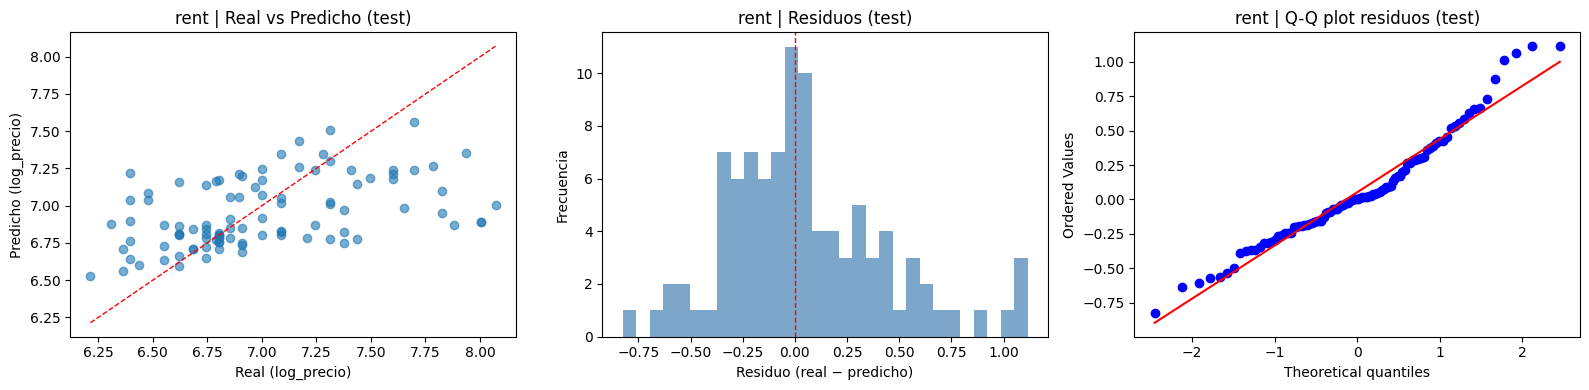


DATASET: SALE  (venta_idealista_clean.csv)

Columnas disponibles: ['fuente', 'tipo_inmueble', 'subtipo', 'direccion_texto', 'barrio_zona', 'municipio', 'precio_eur', 'garaje_incluido', 'habitaciones', 'superficie_m2', 'planta', 'exterior', 'ascensor', 'obra_nueva', 'finca']
Filas originales: 851
Target 'log_precio' creado desde 'precio_eur'
Filas con precio válido: 851
Detectando outliers en el target:
  Rango válido de log_precio: [11.1477, 14.4450]
  Outliers eliminados: 13 de 851 (1.5%)
  log_precio eliminados: [14.877 14.963 14.88  14.875 11.002 14.496 14.875 14.732 14.604 11.002
 14.67  14.483 14.457]
  Precio equivalente (€): [2890000 3150000 2900000 2884000   60000 1975000 2885000 2500000 2200000
   60000 2350000 1950000 1900000]
Filas tras limpieza: 838
Features usados (9): ['habitaciones', 'superficie_m2', 'exterior', 'ascensor', 'garaje_incluido', 'obra_nueva', 'tipo_inmueble', 'subtipo', 'municipio']
Train: 670 filas | Test: 168 filas

Buscando mejores hiperparametros (50 c

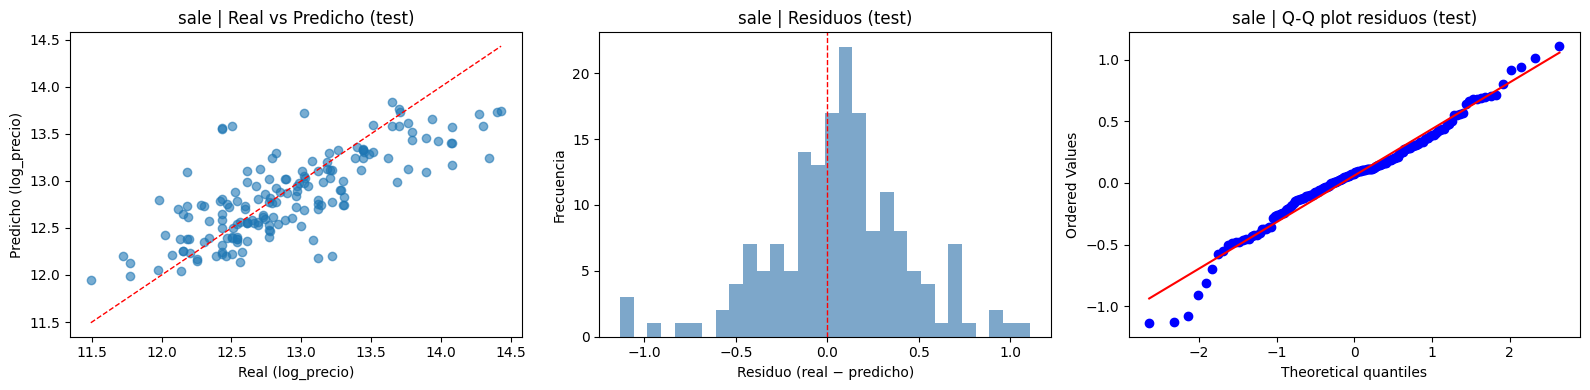


RESUMEN GLOBAL
dataset  n_filas_limpias  n_features_model  train_RMSE  cv_RMSE  test_RMSE  train_R2  test_R2  ratio_RMSE_test_train  delta_R2_train_test
   rent              487               130      0.2385   0.2753     0.3895    0.5881   0.2126                 1.6327               0.3755
   sale              838                94      0.3216   0.3726     0.3817    0.7087   0.5778                 1.1867               0.1309


,dataset,n_filas_limpias,n_features_model,train_RMSE,cv_RMSE,test_RMSE,train_R2,test_R2,ratio_RMSE_test_train,delta_R2_train_test
0,rent,487,130,0.238535,0.275272,0.389456,0.588098,0.212603,1.632699,0.375495
1,sale,838,94,0.321648,0.372646,0.381694,0.708702,0.577821,1.186683,0.130881


In [4]:
all_rows = []

for dataset_name, dataset_path in DATASETS.items():
    cfg = DATASET_CONFIG[dataset_name]
    price_col = cfg["price_col"]

    print()
    print("=" * 100)
    print(f"DATASET: {dataset_name.upper()}  ({dataset_path.name})")

    # ── Carga de datos ────────────────────────────────────────────────────────
    df = pd.read_csv(dataset_path, sep=";")
    print(f"\nColumnas disponibles: {df.columns.tolist()}")
    print(f"Filas originales: {len(df)}")

    # ── Creación del target log_precio ────────────────────────────────────────
    if price_col not in df.columns:
        raise ValueError(f"No existe la columna de precio '{price_col}' en {dataset_name}")

    df = df[df[price_col].notna() & (df[price_col] > 0)].copy()
    df[TARGET_COL] = np.log(df[price_col])
    print(f"Target '{TARGET_COL}' creado desde '{price_col}'")
    print(f"Filas con precio válido: {len(df)}")

    # ── Eliminación de outliers ───────────────────────────────────────────────
    print("Detectando outliers en el target:")
    df = remove_outliers(df)
    print(f"Filas tras limpieza: {len(df)}")

    # ── Construcción de features y split train/test ───────────────────────────
    features, missing = build_feature_list(df, cfg["features"])
    X = df[features].copy()
    y = df[TARGET_COL].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    print(f"Features usados ({len(features)}): {features}")
    if missing:
        print(f"Features ausentes (ignorados): {missing}")
    print(f"Train: {len(X_train)} filas | Test: {len(X_test)} filas")

    # ── Entrenamiento con búsqueda de hiperparámetros ─────────────────────────
    print(f"\nBuscando mejores hiperparametros ({N_ITER_SEARCH} combinaciones, CV={N_SPLITS} folds)...")
    res = evaluate_rf(X_train, X_test, y_train, y_test)

    # ── Resultados ────────────────────────────────────────────────────────────
    print("\nMejores hiperparametros encontrados:")
    for param, val in sorted(res["best_params"].items()):
        print(f"  {param.replace('rf__', '')}: {val}")

    detail = pd.DataFrame([
        {"split": "train", **res["train"]},
        {"split": "CV",    "MSE": None, "RMSE": res["cv_rmse"], "MAE": None, "MAPE": None, "R2": None, "R2_ajustado": None},
        {"split": "test",  **res["test"]},
    ])
    print("\nMetricas (train / CV / test):")
    print(detail.round(5).to_string(index=False))

    print(
        f"\nSobreajuste → ratio RMSE test/train: {res['overfit']['ratio_RMSE_test_train']:.4f}"
        f" | delta R2 train-test: {res['overfit']['delta_R2_train_test']:.4f}"
    )

    print("\nTop 15 importancias de features:")
    print(res["importances"].round(5).to_string(index=False))

    # ── Gráficos diagnósticos ─────────────────────────────────────────────────
    residuals = y_test - res["pred_test"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    ax = axes[0]
    ax.scatter(y_test, res["pred_test"], alpha=0.6)
    lim = [min(y_test.min(), res["pred_test"].min()), max(y_test.max(), res["pred_test"].max())]
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_title(f"{dataset_name} | Real vs Predicho (test)")
    ax.set_xlabel("Real (log_precio)")
    ax.set_ylabel("Predicho (log_precio)")

    ax = axes[1]
    ax.hist(residuals, bins=30, alpha=0.7, color="steelblue")
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{dataset_name} | Residuos (test)")
    ax.set_xlabel("Residuo (real − predicho)")
    ax.set_ylabel("Frecuencia")

    ax = axes[2]
    stats.probplot(residuals, dist="norm", plot=ax)
    ax.set_title(f"{dataset_name} | Q-Q plot residuos (test)")
    ax.get_lines()[1].set_color("red")

    plt.tight_layout()
    plt.show()

    # ── Acumulación para el resumen final ─────────────────────────────────────
    all_rows.append({
        "dataset":               dataset_name,
        "n_filas_limpias":       len(df),
        "n_features_model":      res["p_features"],
        "train_RMSE":            res["train"]["RMSE"],
        "cv_RMSE":               res["cv_rmse"],
        "test_RMSE":             res["test"]["RMSE"],
        "train_R2":              res["train"]["R2"],
        "test_R2":               res["test"]["R2"],
        "ratio_RMSE_test_train": res["overfit"]["ratio_RMSE_test_train"],
        "delta_R2_train_test":   res["overfit"]["delta_R2_train_test"],
    })

# ── Resumen global ────────────────────────────────────────────────────────────
summary = pd.DataFrame(all_rows).reset_index(drop=True)
print()
print("=" * 100)
print("RESUMEN GLOBAL")
print(summary.round(4).to_string(index=False))
summary